# RF3 for Antibody/Antigen Structure Prediction

Worked examples for [**RF3**](https://github.com/RosettaCommons/foundry) and [**AtomWorks**](https://github.com/RosettaCommons/atomworks), covering common antibody and immunogen structure prediction workflows.

### RF3 Overview

RF3 exhibits strong performance at antibody–antigen structure prediction, as validated by the external [FoldBench](https://github.com/BEAM-Labs/FoldBench) benchmark:

| Model | Protein–Protein | Antibody–Antigen | Protein–Ligand |
|-------|----------------|-----------------|---------------|
| **RosettaFold3*** | **72.44%** | **37.50%** | **57.28%** |
| AlphaFold 3 | 70.87% | 47.95% | 67.59% |
| Boltz-2* | 70.54% | 25.00% | 53.90% |
| OpenFold 3 (preview) | 68.22% | 34.29% | 40.85% |
| Chai-1 | 66.95% | 18.31% | 49.28% |
| HelixFold 3 | 66.67% | 28.17% | 50.68% |
| Protenix | 64.80% | 38.36% | 53.25% |
| Boltz-1 | 64.10% | 31.43% | 51.33% |

### Tutorial Overview

| Section | Topic |
|---------|-------|
| 1 | AtomWorks — loading & visualizing structures |
| 2 | Nanobody (VHH) prediction |
| 3 | Paired antibody (Fab) prediction |
| 4 | Antibody/antigen complex prediction |
| 5 | Template-guided prediction |
| 6 | Tips & practical guidance |

**Requirements:** Python 3.12, CUDA GPU, [`rc-foundry[all]`](https://github.com/RosettaCommons/foundry), [`atomworks[ml]`](https://github.com/RosettaCommons/atomworks)


---
## Section 0: Setup & Environment


### Installation

```bash
uv pip install "rc-foundry[all]" "atomworks[ml]" py3Dmol matplotlib pandas
foundry install base-models  # download RF3 weights (~2 GB)
```

See the [Foundry README](https://github.com/RosettaCommons/foundry#installation) for full installation instructions.

In [1]:
!uv pip install "rc-foundry[all]" "atomworks[ml]" py3Dmol matplotlib pandas

Audited 5 packages in 10ms


### Tutorial data

Reference crystal structures, pre-computed MSAs, and RF3 input files are included in the `data/` directory.


In [2]:
# Suppress noisy library warnings
import warnings
import logging
import os
warnings.filterwarnings("ignore")
logging.disable(logging.WARNING)
os.environ["PYTHONWARNINGS"] = "ignore"

# Verify GPU
import torch
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


GPU available: True
GPU: NVIDIA H200


In [3]:
# Core imports
import json
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import py3Dmol

import biotite.structure as struc
from atomworks.io.parser import parse
from atomworks.io.utils.visualize import view

from helpers import *

# RF3 inference engine — initialized once, reused for all predictions
from rf3.inference_engines.rf3 import RF3InferenceEngine
from rf3.utils.inference import InferenceInput

engine = RF3InferenceEngine(ckpt_path='rf3', verbose=False)

# Paths
DATA_DIR = Path("data")
INPUT_DIR = DATA_DIR / "inputs"
MSA_DIR = DATA_DIR / "msas"
REF_DIR = DATA_DIR / "references"

# Temp dir for intermediate CIF files (used by template predictions)
TMPDIR = Path(tempfile.mkdtemp(prefix="rf3_tutorial_"))


def run_rf3(input_json: dict) -> tuple:
    """Run RF3 on a single input dict. Returns (AtomArray, summary_confidences, confidences).

    Results are returned in memory. To write CIF and confidence files to disk instead:
        results = engine.run(inputs=inp, out_dir="path/to/output")
    """
    inp = InferenceInput.from_json_dict(input_json)
    results = engine.run(inputs=inp)
    out = list(results.values())[0][0]
    # Annotate b_factor with pLDDT so view_by_plddt() works
    if out.confidences and "atom_plddts" in out.confidences:
        out.atom_array.b_factor = np.array(out.confidences["atom_plddts"])
    return out.atom_array, out.summary_confidences, out.confidences


def run_rf3_from_file(json_path: str | Path) -> tuple:
    """Load a JSON input file and run RF3."""
    with open(json_path) as f:
        data = json.load(f)
    return run_rf3(data[0])



print("Setup complete — RF3 engine loaded.")


Setup complete — RF3 engine loaded.


---
## Section 1: AtomWorks — Loading & Visualizing Structures

Quick introduction to [AtomWorks](https://github.com/RosettaCommons/atomworks) (built on [Biotite](https://www.biotite-python.org/)) for loading, selecting, and visualizing protein structures.


Load the anti-GFP nanobody crystal structure ([PDB: 3OGO](https://www.rcsb.org/structure/3OGO)).


In [4]:
# Load the crystal structure with AtomWorks
struct_3ogo = load_structure(str(REF_DIR / "3OGO.cif"))

print(f"Total atoms: {len(struct_3ogo)}")
print(f"Chains: {sorted(set(str(c) for c in struct_3ogo.chain_id))}")


Total atoms: 10891
Chains: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K']


In [5]:
# Extract nanobody chain E and inspect
nanobody_xtal = struct_3ogo[struct_3ogo.chain_id == "E"]
seq = extract_sequence(nanobody_xtal)
print(f"Nanobody: {len(nanobody_xtal)} atoms, {len(seq)} residues")
print(f"Sequence: {seq}")


Nanobody: 893 atoms, 115 residues
Sequence: QVQLVESGGALVQPGGSLRLSCAASGFPVNRYSMRWYRQAPGKEREWVAGMSSAGDRSSYEDSVKGRFTISRDDARNTVYLQMNSLKPEDTAVYYCNVNVGFEYWGQGTQVTVSS


In [6]:
# Visualize
view(nanobody_xtal)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

---
## Section 2: Nanobody (VHH) Structure Prediction

Quick first RF3 prediction: the anti-GFP nanobody from [3OGO](https://www.rcsb.org/structure/3OGO), predicted **from sequence + MSA**.


### 2.1 The RF3 input JSON

RF3 takes a [JSON input file](https://github.com/RosettaCommons/foundry#input-format) describing the molecules to predict.


In [7]:
# Examine the RF3 input file
with open(INPUT_DIR / "nanobody_vhh.json") as f:
    nanobody_input = json.load(f)

print(json.dumps(nanobody_input, indent=2))


[
  {
    "name": "nanobody_3ogo",
    "components": [
      {
        "seq": "MQVQLVESGGALVQPGGSLRLSCAASGFPVNRYSMRWYRQAPGKEREWVAGMSSAGDRSSYEDSVKGRFTISRDDARNTVYLQMNSLKPEDTAVYYCNVNVGFEYWGQGTQVTVSS",
        "msa_path": "data/msas/nanobody_3ogo.a3m",
        "chain_id": "A"
      }
    ]
  }
]


Key fields:
- **`name`** — identifier for this prediction
- **`seq`** — amino acid sequence (one-letter code)
- **`chain_id`** — chain label in the output structure
- **`msa_path`** — path to a pre-computed MSA ([A3M format](https://github.com/soedinglab/hh-suite/wiki#generating-a-multiple-sequence-alignment-using-hhblits))


### 2.2 Run RF3

Workshop settings: `num_steps=50` (vs 200 production), `n_recycles=3` (vs 10). See Section 7 for guidance on production settings.


In [8]:
nanobody_pred, nanobody_conf, nanobody_conf_detail = run_rf3_from_file(INPUT_DIR / "nanobody_vhh.json")
print(f"Predicted structure: {len(nanobody_pred)} atoms")


Predicted structure: 901 atoms


### 2.3 Examine output files

RF3 produces several output files for each prediction.

RF3 returns results directly in memory as `RF3Output` objects containing the predicted `AtomArray` and confidence metrics.

To write CIF structures and confidence JSONs to disk instead, pass `out_dir`:
```python
engine.run(inputs=inp, out_dir="outputs/nanobody")
```


Key outputs:
- `*_model.cif` — predicted 3D structure (mmCIF format)
- `*_confidences.json` — per-atom pLDDT and PAE matrix
- `*_summary_confidences.json` — overall pLDDT, pTM, iPTM, min iPAE


### 2.4 Visualize the prediction

In [9]:
# Prediction is already in memory from the run above
print(f"Predicted structure: {len(nanobody_pred)} atoms")
print(f"Summary confidences: {json.dumps(nanobody_conf, indent=2)}")


Predicted structure: 901 atoms
Summary confidences: {
  "chain_ptm": [
    0.92
  ],
  "chain_pair_pae_min": [
    [
      null
    ]
  ],
  "chain_pair_pde_min": [
    [
      null
    ]
  ],
  "chain_pair_pae": [
    [
      null
    ]
  ],
  "chain_pair_pde": [
    [
      null
    ]
  ],
  "overall_plddt": 0.9163,
  "overall_pde": 0.3423,
  "overall_pae": 1.3281,
  "ptm": 0.9591241478919983,
  "iptm": 0.0,
  "has_clash": false,
  "ranking_score": 0.1918
}


In [10]:
# View the prediction colored by chain
view(nanobody_pred)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [11]:
# View colored by pLDDT (confidence)
# Note: 3OGO is in the RF3 training set, so this prediction will be very confident.
# Expect lower pLDDT on novel targets, especially at CDR loops and interfaces.
view_by_plddt(nanobody_pred)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### 2.5 Compare to crystal structure

In [12]:
# Superimpose prediction onto crystal structure and compute Cα RMSD
fitted_pred, rmsd_val = superimpose_and_rmsd(nanobody_xtal, nanobody_pred)
print(f"Cα RMSD to crystal: {rmsd_val:.2f} Å")

Cα RMSD to crystal: 0.57 Å


In [13]:
# Overlay prediction (blue) and crystal (orange)
view_overlay(fitted_pred, nanobody_xtal, label1="RF3 Prediction", label2="Crystal (3OGO)")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

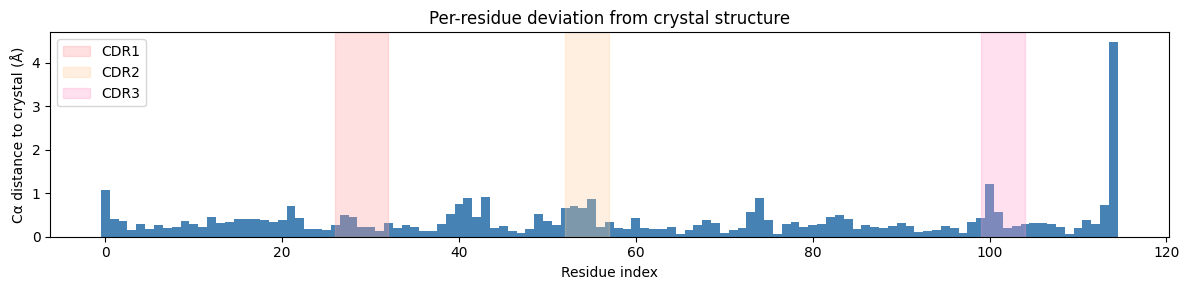

In [14]:
# Per-residue distance to crystal — where does the prediction deviate?
per_res = per_residue_rmsd(nanobody_xtal, nanobody_pred)

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(range(len(per_res)), per_res, color="steelblue", width=1.0)
ax.set_xlabel("Residue index")
ax.set_ylabel("Cα distance to crystal (Å)")
ax.set_title("Per-residue deviation from crystal structure")

# CDR regions (VDJ scheme, from ANARCI/HMM annotation)
cdrs = [(26, 32, "CDR1"), (52, 57, "CDR2"), (99, 104, "CDR3")]
colors = ["#ff9999", "#ffcc99", "#ff99cc"]
for (start, end, label), color in zip(cdrs, colors):
    ax.axvspan(start, end, alpha=0.3, color=color, label=label)
ax.legend()
plt.tight_layout()
plt.show()


**Observations:** Framework regions are predicted with high accuracy (<1 Å deviation). CDR loops — especially CDR3 — show more deviation than their surrounding residues, reflecting their conformational diversity.


---
## Section 3: Paired Antibody (Fab) Prediction

Predict a full **Fab fragment** (VH + VL) of Trastuzumab (Herceptin), a therapeutic anti-HER2 antibody ([PDB: 1N8Z](https://www.rcsb.org/structure/1N8Z)).

This introduces **multi-chain prediction** and **MSA-guided** folding. Each chain gets its own MSA, and RF3 predicts their paired structure.


In [15]:
# Look at the multi-chain input
with open(INPUT_DIR / "trastuzumab_fab.json") as f:
    fab_input = json.load(f)

print(json.dumps(fab_input, indent=2))

[
  {
    "name": "trastuzumab_fab",
    "components": [
      {
        "seq": "EVQLVESGGGLVQPGGSLRLSCAASGFNIKDTYIHWVRQAPGKGLEWVARIYPTNGYTRYADSVKGRFTISADTSKNTAYLQMNSLRAEDTAVYYCSRWGGDGFYAMDYWGQGTLVTVSSASTKGPSVFPLAPSSKSTSGGTAALGCLVKDYFPEPVTVSWNSGALTSGVHTFPAVLQSSGLYSLSSVVTVPSSSLGTQTYICNVNHKPSNTKVDKKVEP",
        "msa_path": "data/msas/trastuzumab_vh.a3m",
        "chain_id": "H"
      },
      {
        "seq": "DIQMTQSPSSLSASVGDRVTITCRASQDVNTAVAWYQQKPGKAPKLLIYSASFLYSGVPSRFSGSRSGTDFTLTISSLQPEDFATYYCQQHYTTPPTFGQGTKVEIKRTVAAPSVFIFPPSDEQLKSGTASVVCLLNNFYPREAKVQWKVDNALQSGNSQESVTEQDSKDSTYSLSSTLTLSKADYEKHKVYACEVTHQGLSSPVTKSFNRGEC",
        "msa_path": "data/msas/trastuzumab_vl.a3m",
        "chain_id": "L"
      }
    ]
  }
]


Key additions vs. single-chain:
- Two `components` with separate `chain_id` values (`"H"` and `"L"`)
- Each has its own `msa_path`


In [16]:
fab_pred, fab_conf, fab_conf_detail = run_rf3_from_file(INPUT_DIR / "trastuzumab_fab.json")
print(f"Fab prediction: {len(fab_pred)} atoms")


Fab prediction: 3298 atoms


In [17]:
# Load reference crystal structure
fab_ref = load_structure(str(REF_DIR / "1N8Z.cif"))

print(f"Prediction chains: {sorted(set(fab_pred.chain_id))}")
print(f"Reference chains: {sorted(set(fab_ref.chain_id))}")


Prediction chains: [np.str_('H'), np.str_('L')]
Reference chains: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E')]


In [18]:
# Visualize colored by chain
view(fab_pred)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [19]:
# View colored by pLDDT
view_by_plddt(fab_pred)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### PAE (Predicted Aligned Error)

The PAE matrix shows RF3's confidence in the **relative positions** of all residue pairs. For multi-chain predictions, look at the **off-diagonal blocks** — low PAE between chains means RF3 is confident about their relative arrangement.


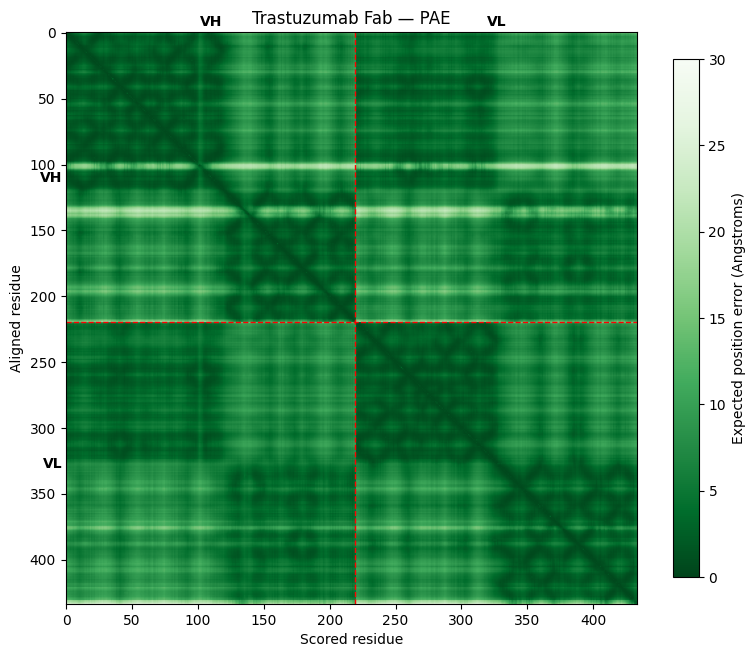

In [20]:
# Load and plot PAE
if fab_conf_detail and "pae" in fab_conf_detail:
    pae = np.array(fab_conf_detail["pae"])
    pred_h = fab_pred[fab_pred.chain_id == "H"]
    n_h = len(pred_h[pred_h.atom_name == "CA"])

    plot_pae(
        pae,
        chain_breaks=[n_h],
        chain_labels=["VH", "VL"],
        title="Trastuzumab Fab — PAE",
    )
    plt.show()
else:
    print("PAE matrix not available.")


In [21]:
# Quantitative comparison — need to match chains between pred and reference
# 1N8Z uses chain A (light) and B (heavy)
ref_h = fab_ref[fab_ref.chain_id == "B"]
ref_l = fab_ref[fab_ref.chain_id == "A"]
pred_h = fab_pred[fab_pred.chain_id == "H"]
pred_l = fab_pred[fab_pred.chain_id == "L"]

_, rmsd_h = superimpose_and_rmsd(ref_h, pred_h)
_, rmsd_l = superimpose_and_rmsd(ref_l, pred_l)

print(f"VH Cα RMSD: {rmsd_h:.2f} Å")
print(f"VL Cα RMSD: {rmsd_l:.2f} Å")

VH Cα RMSD: 0.87 Å
VL Cα RMSD: 0.50 Å


---
## Section 4: Antibody/Antigen Complex Prediction

Predict the **CR3022 Fab** bound to the **SARS-CoV-2 RBD** ([PDB: 6W41](https://www.rcsb.org/structure/6W41)). CR3022 is a well-characterized SARS-CoV cross-reactive antibody.

**Important context:** Antibody/antigen docking from MSAs alone is one of the hardest tasks in structure prediction. Unlike VH/VL pairing (Section 3), there is no strong evolutionary covariance signal between antibody and antigen sequences. RF3 may fold each chain correctly but struggle to find the correct binding interface. This motivates the **template-guided approaches** in Section 5.


In [22]:
# Look at the complex input — 3 chains: VH, VL, and antigen
with open(INPUT_DIR / "cr3022_rbd_complex.json") as f:
    complex_input = json.load(f)
print(json.dumps(complex_input, indent=2))

[
  {
    "name": "cr3022_rbd_complex",
    "components": [
      {
        "seq": "QMQLVQSGTEVKKPGESLKISCKGSGYGFITYWIGWVRQMPGKGLEWMGIIYPGDSETRYSPSFQGQVTISADKSINTAYLQWSSLKASDTAIYYCAGGSGISTPMDVWGQGTTVTVSSASTKGPSVFPLAPSSKSTSGGTAALGCLVKDYFPEPVTVSWNSGALTSGVHTFPAVLQSSGLYSLSSVVTVPSSSLGTQTYICNVNHKPSNTKVDKKVEPKSC",
        "msa_path": "data/msas/cr3022_vh.a3m",
        "chain_id": "H"
      },
      {
        "seq": "DIQLTQSPDSLAVSLGERATINCKSSQSVLYSSINKNYLAWYQQKPGQPPKLLIYWASTRESGVPDRFSGSGSGTDFTLTISSLQAEDVAVYYCQQYYSTPYTFGQGTKVEIKRTVAAPSVFIFPPSDEQLKSGTASVVCLLNNFYPREAKVQWKVDNALQSGNSQESVTEQDSKDSTYSLSSTLTLSKADYEKHKVYACEVTHQGLSSPVTKSFNRGECS",
        "msa_path": "data/msas/cr3022_vl.a3m",
        "chain_id": "L"
      },
      {
        "seq": "RVQPTESIVRFPNITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKSTNLVKNKCVNF",
        "msa_path": "data/msas/sa

In [23]:
complex_pred, complex_conf, complex_conf_detail = run_rf3_from_file(INPUT_DIR / "cr3022_rbd_complex.json")
print(f"Complex prediction: {len(complex_pred)} atoms")


Complex prediction: 5132 atoms


In [24]:
complex_ref = load_structure(str(REF_DIR / "6W41.cif"))

print(f"Predicted chains: {sorted(set(complex_pred.chain_id))}")
print(f"Reference chains: {sorted(set(complex_ref.chain_id))}")


Predicted chains: [np.str_('A'), np.str_('H'), np.str_('L')]
Reference chains: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('G')]


In [25]:
# Visualize the predicted complex — color by chain
view(complex_pred)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [26]:
# View colored by pLDDT — shows per-residue confidence
# High confidence (blue) in framework regions, lower (yellow/red) at interfaces and loops
view_by_plddt(complex_pred)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [27]:
# Confidence metrics — focus on min iPAE for interface quality
# Anything < 5 is typically a good interface, but this can vary by target and application
print_confidence_summary({"summary": complex_conf}, ["RBD(A)", "VH(H)", "VL(L)"])


pLDDT: 0.813  |  iPTM: 0.578
  min iPAE RBD(A) – VH(H): 13.9
  min iPAE RBD(A) – VL(L): 13.7
  min iPAE VH(H) – VL(L): 1.0


### Understanding min iPAE

`chain_pair_pae_min` (min iPAE) is the key interface confidence metric. It reports the **minimum predicted aligned error** between each pair of chains — how confident the model is about the best-resolved part of the interface.

| min iPAE | Interpretation |
|----------|---------------|
| **< 5**  | High confidence — interface likely correct |
| **5–12** | Moderate — some contacts may be right |
| **> 12** | Low confidence — docking is uncertain |

VH–VL min iPAE is typically very low (conserved pairing). The **antibody–antigen** min iPAE is the critical value.


### PAE Heatmap — Interface Confidence

For complex prediction, the PAE heatmap is the most informative quality metric. Look at the **off-diagonal blocks** between antibody and antigen chains.

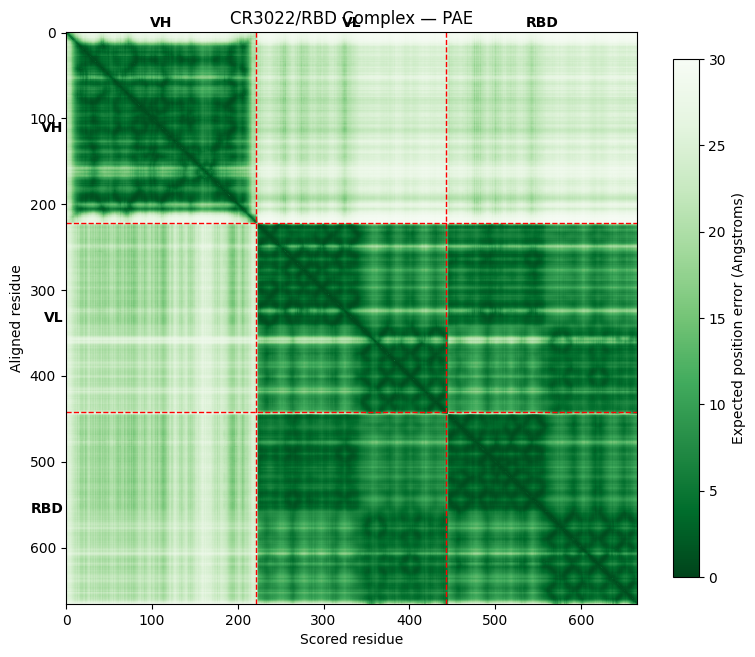

In [28]:
if complex_conf_detail and "pae" in complex_conf_detail:
    pae = np.array(complex_conf_detail["pae"])
    n_h = np.sum((complex_pred.chain_id == "H") & (complex_pred.atom_name == "CA"))
    n_l = np.sum((complex_pred.chain_id == "L") & (complex_pred.atom_name == "CA"))

    plot_pae(
        pae,
        chain_breaks=[n_h, n_h + n_l],
        chain_labels=["VH", "VL", "RBD"],
        title="CR3022/RBD Complex — PAE",
    )
    plt.show()
else:
    print("PAE not available.")


**Reading the PAE heatmap:**
- **Diagonal blocks** (VH–VH, VL–VL, RBD–RBD): intra-chain confidence — should be low (good)
- **VH–VL block**: antibody interface — usually confident for paired Fabs
- **VH–RBD and VL–RBD blocks**: the antibody–antigen interface — low PAE here means confident docking


In [29]:
# Quantitative comparison to crystal
# 6W41 chains in CIF: A (heavy), B (light), C (RBD)
ref_h = complex_ref[complex_ref.chain_id == "A"]
ref_l = complex_ref[complex_ref.chain_id == "B"]
ref_rbd = complex_ref[complex_ref.chain_id == "C"]

pred_h = complex_pred[complex_pred.chain_id == "H"]
pred_l = complex_pred[complex_pred.chain_id == "L"]
pred_rbd = complex_pred[complex_pred.chain_id == "A"]

_, rmsd_h = superimpose_and_rmsd(ref_h, pred_h)
_, rmsd_l = superimpose_and_rmsd(ref_l, pred_l)
_, rmsd_rbd = superimpose_and_rmsd(ref_rbd, pred_rbd)

print(f"VH Cα RMSD:  {rmsd_h:.2f} Å")
print(f"VL Cα RMSD:  {rmsd_l:.2f} Å")
print(f"RBD Cα RMSD: {rmsd_rbd:.2f} Å")


VH Cα RMSD:  1.16 Å
VL Cα RMSD:  0.52 Å
RBD Cα RMSD: 0.71 Å


### Interpreting the result

RF3 folds each chain correctly, but the min iPAE between antibody and antigen is high — the model is **not confident about the docking interface**. This is typical: antibody/antigen interfaces lack the evolutionary covariance signal that makes VH/VL pairing (Section 3) reliable.

For larger antigens the problem is worse and prediction is much slower. **Templates** (Section 6) solve both problems — they provide the missing structural context and reduce the search space.


---
## Section 5: Template-Guided Prediction

RF3's [templating system](https://github.com/RosettaCommons/foundry#templates) lets you **fix known structural regions** and predict only the unknown parts. This is the key to reliable Ab/Ag complex prediction.

**How it works:**
- Provide a structure via `"path"` in the JSON component
- Use `"template_selection"` to specify which residues to fix
- Syntax: `"CHAIN/RESNAME/RESID_RANGE"` — e.g., `"B/*/1-42"` fixes residues 1–42 of chain B
- Unfixed residues are predicted from scratch by the diffusion model


### Crop & template an antigen structure

**Use case:** You have a crystal structure of your antigen, but the PDB file contains extra chains you don't need.

This is the most common real-world scenario. work with [6M0J](https://www.rcsb.org/structure/6M0J) (ACE2–RBD complex, 791 residues total) and extract just the **RBD** (194 residues) for use as a template.


In [30]:
# Load the full experimental structure
full_6m0j = load_structure(str(REF_DIR / "6M0J.cif"))

# Inspect — what chains are present?
for c in sorted(set(str(x) for x in full_6m0j.chain_id)):
    ca = full_6m0j[(full_6m0j.chain_id == c) & (full_6m0j.atom_name == "CA")]
    if len(ca) > 0:
        print(f"  Chain {c}: {len(ca)} residues (res_id {ca.res_id.min()}-{ca.res_id.max()})")

print(f"\nTotal: {np.sum(full_6m0j.atom_name == 'CA')} residues")
print("We only need chain B (the RBD, 194 residues) -- chain A is ACE2.")


  Chain A: 597 residues (res_id 1-597)
  Chain B: 194 residues (res_id 15-208)

Total: 791 residues
We only need chain B (the RBD, 194 residues) -- chain A is ACE2.


In [31]:
# Step 1: Crop to just the RBD chain
rbd_only = full_6m0j[full_6m0j.chain_id == "B"]
print(f"Cropped: {np.sum(rbd_only.atom_name == 'CA')} residues")

# Step 2: Rename the chain to avoid conflicts
# The antibody will use chains H and L. If the antigen were also chain H,
# RF3's template_selection wouldn't know which chain to fix.
# We rename RBD to chain R.
rbd_only = rbd_only.copy()
rbd_only.chain_id[:] = "R"

# Step 3: Save the cropped template

rbd_template_path = str(REF_DIR / "6M0J_rbd_only.cif")
to_cif_file(rbd_only, rbd_template_path)

print(f"Saved cropped template to {rbd_template_path}")
print(f"Chain: {sorted(set(str(c) for c in rbd_only.chain_id))}, "
      f"{np.sum(rbd_only.atom_name == 'CA')} residues")


Cropped: 194 residues
Saved cropped template to data/references/6M0J_rbd_only.cif
Chain: ['R'], 194 residues


In [32]:
template_6c = {
    "name": "template_experimental_antigen",
    "components": [
        {"path": rbd_template_path},
        {
            "seq": complex_input[0]["components"][0]["seq"],
            "msa_path": "data/msas/cr3022_vh.a3m",
            "chain_id": "H",
        },
        {
            "seq": complex_input[0]["components"][1]["seq"],
            "msa_path": "data/msas/cr3022_vl.a3m",
            "chain_id": "L",
        },
    ],
    "template_selection": ["R"],
}
print(json.dumps(template_6c, indent=2))


{
  "name": "template_experimental_antigen",
  "components": [
    {
      "path": "data/references/6M0J_rbd_only.cif"
    },
    {
      "seq": "QMQLVQSGTEVKKPGESLKISCKGSGYGFITYWIGWVRQMPGKGLEWMGIIYPGDSETRYSPSFQGQVTISADKSINTAYLQWSSLKASDTAIYYCAGGSGISTPMDVWGQGTTVTVSSASTKGPSVFPLAPSSKSTSGGTAALGCLVKDYFPEPVTVSWNSGALTSGVHTFPAVLQSSGLYSLSSVVTVPSSSLGTQTYICNVNHKPSNTKVDKKVEPKSC",
      "msa_path": "data/msas/cr3022_vh.a3m",
      "chain_id": "H"
    },
    {
      "seq": "DIQLTQSPDSLAVSLGERATINCKSSQSVLYSSINKNYLAWYQQKPGQPPKLLIYWASTRESGVPDRFSGSGSGTDFTLTISSLQAEDVAVYYCQQYYSTPYTFGQGTKVEIKRTVAAPSVFIFPPSDEQLKSGTASVVCLLNNFYPREAKVQWKVDNALQSGNSQESVTEQDSKDSTYSLSSTLTLSKADYEKHKVYACEVTHQGLSSPVTKSFNRGECS",
      "msa_path": "data/msas/cr3022_vl.a3m",
      "chain_id": "L"
    }
  ],
  "template_selection": [
    "R"
  ]
}


In [33]:
t6c_pred, t6c_conf, _ = run_rf3(template_6c)
print(f"Template 6c prediction: {len(t6c_pred)} atoms")


Template 6c prediction: 4897 atoms


In [34]:
view(t6c_pred)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [35]:
view_by_plddt(t6c_pred)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Key points:**
- **Always inspect chains** before templating — PDB files often contain binding partners, symmetry mates, or other unwanted molecules
- **Rename chains** that would clash with antibody chain IDs (H, L)
- Crystal/cryo-EM templates are more reliable than predicted ones


### Tips

- **Crop to the binding domain** — include 10–20 residues of buffer around the epitope for structural context
- **Rename chains** to avoid conflicts with antibody chains (H, L)
- You can also template a **predicted** antigen structure (e.g. from an RF3 monomer prediction or [AlphaFold DB](https://alphafold.ebi.ac.uk/)) — just replace the `"path"` in the template input
- The more you template, the more confident the model will be — confidence metrics should not be directly compared across approaches with different amounts of templating


---
## Section 6: Tips & Practical Guidance


### Speed vs. quality

| Setting | `num_steps` | `n_recycles` | `diffusion_batch_size` | Use case |
|---------|------------|-------------|----------------------|----------|
| Quick | 50 | 3 | 1 | Exploration, workshops |
| Production | 200 | 10 | 5–10 | Final predictions, publications |

### When to use templates vs. MSAs

| Scenario | Approach |
|----------|----------|
| Sequence only | MSA-only prediction |
| Crystal/cryo-EM structure of antigen | Crop to binding domain, template it |
| Predicted structure of antigen | Template (verify prediction quality first) |
| Known antibody framework | Template framework, predict CDRs |
| Both structures known | Template both, predict CDRs in antigen context |

### Confidence metrics

| Metric | What it measures | Confident |
|--------|-----------------|----------|
| **pLDDT** | Per-residue fold confidence (0–1) | > 0.9 very high, > 0.7 confident |
| **min iPAE** | Best interface contact confidence | < 5 high, 5–12 moderate, > 12 low |
| **iPTM** | Overall interface quality | > 0.8 |
| **pTM** | Overall fold quality | > 0.8 |
| **PAE matrix** | Pairwise position confidence | Visual — check off-diagonal blocks |

For complex predictions, **min iPAE** (`chain_pair_pae_min`) is the most reliable interface metric. iPTM averages over all inter-chain pairs and can be diluted by large domains.


---
## Resources

- **RF3 (Foundry):** [github.com/RosettaCommons/foundry](https://github.com/RosettaCommons/foundry)
- **AtomWorks:** [github.com/RosettaCommons/atomworks](https://github.com/RosettaCommons/atomworks)
- **RFantibody** (antibody design): [github.com/RosettaCommons/RFantibody](https://github.com/RosettaCommons/RFantibody)
- **Biotite** (structural bioinformatics): [biotite-python.org](https://www.biotite-python.org/)
- **py3Dmol** (3D visualization): [3dmol.csb.pitt.edu](https://3dmol.csb.pitt.edu/)
- **ColabFold** (MSA generation): [github.com/sokrypton/ColabFold](https://github.com/sokrypton/ColabFold)

### PDB structures used

| PDB | Description |
|-----|------------|
| [3OGO](https://www.rcsb.org/structure/3OGO) | Anti-GFP nanobody (VHH) |
| [1N8Z](https://www.rcsb.org/structure/1N8Z) | Trastuzumab Fab / HER2 complex |
| [6M0J](https://www.rcsb.org/structure/6M0J) | ACE2 / SARS-CoV-2 RBD complex |
| [6W41](https://www.rcsb.org/structure/6W41) | CR3022 Fab / SARS-CoV-2 RBD complex |
